<a href="https://colab.research.google.com/github/drmistretta/PredictCollege/blob/main/Descriptive_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Estimated coefficients (intercept, H5OD2A_numeric): [ 0.13590326 -0.31537636]

Predicted probabilities (first 10): [0.53392362 0.45525177 0.45525177 0.45525177 0.53392362 0.53392362
 0.53392362 0.53392362 0.53392362 0.53392362]
Predicted classes (first 10): [1. 0. 0. 0. 1. 1. 1. 1. 1. 1.]


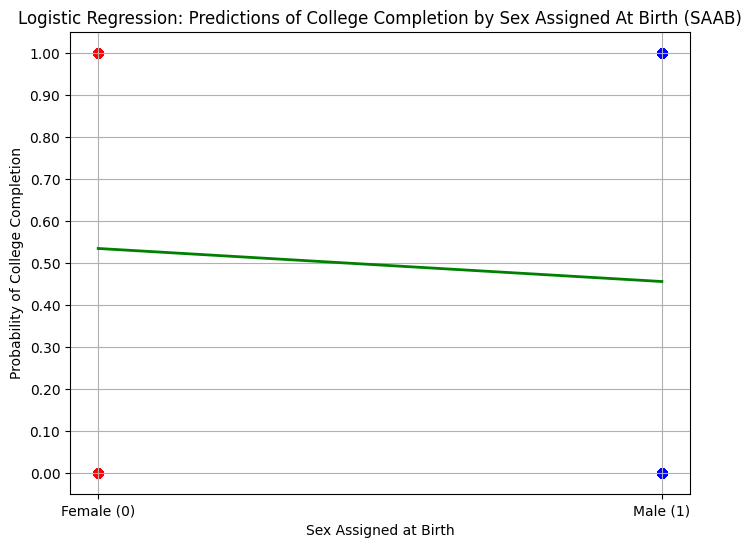

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit  # expit is the logistic (sigmoid) function
from matplotlib.ticker import FuncFormatter

# Load the dataset (adjust the path accordingly)
df = pd.read_csv('/content/drive/Shared drives/Dr. Sharon Mistretta/Add Health/Predict_College/data_with_birth_year.csv')

# Convert H5OD11 to numeric, forcing any errors to NaN and dropping them
df['H5OD11'] = pd.to_numeric(df['H5OD11'], errors='coerce')

# Create a new column to categorize completion status: 1 for completion, 0 for no completion
df['college_completion'] = np.where(df['H5OD11'] >= 9, 1, 0)

# Map H5OD2A (Sex at Birth) from 1/2 to Male/Female and convert it to numeric (1 for Male, 0 for Female)
df['H5OD2A_numeric'] = df['H5OD2A'].map({1: 1, 2: 0})  # 1 for Male, 0 for Female

# Drop rows with missing values
df = df.dropna(subset=['college_completion', 'H5OD2A_numeric'])

# Prepare the X (independent variables) and y (dependent variable)
X = df[['H5OD2A_numeric']].values
y = df['college_completion'].values

# Add a column of ones for the intercept (beta_0)
X = np.hstack([np.ones((X.shape[0], 1)), X])

# Calculate class weights (weights inversely proportional to class frequencies)
class_weights = {0: len(y) / np.sum(y == 0), 1: len(y) / np.sum(y == 1)}
weights = np.array([class_weights[i] for i in y])

# Define the weighted log-likelihood function (negative because we minimize)
def weighted_log_likelihood(beta, X, y, weights):
    p = expit(np.dot(X, beta))  # Use expit directly for the logistic function
    return -np.sum(weights * (y * np.log(p) + (1 - y) * np.log(1 - p)))

# Initial guess for beta (intercept and coefficient)
beta_initial = np.zeros(X.shape[1])

# Minimize the negative weighted log-likelihood to estimate beta coefficients
result = minimize(weighted_log_likelihood, beta_initial, args=(X, y, weights), method='BFGS')

# Get the estimated coefficients
beta_hat = result.x
print("Estimated coefficients (intercept, H5OD2A_numeric):", beta_hat)

# Calculate the predicted probabilities for X
predicted_probs = expit(np.dot(X, beta_hat))

# You can round predicted_probs to get predicted classes (0 or 1)
predicted_classes = np.round(predicted_probs)

# Print predicted probabilities and predicted classes for the first 10 rows
print("\nPredicted probabilities (first 10):", predicted_probs[:10])
print("Predicted classes (first 10):", predicted_classes[:10])

# Plotting the logistic regression results

# Create a plot
plt.figure(figsize=(8, 6))

# Scatter plot of actual data points for males and females based on completion status
males = df[df['H5OD2A_numeric'] == 1]
females = df[df['H5OD2A_numeric'] == 0]

plt.scatter(males['H5OD2A_numeric'], males['college_completion'], color='blue', label='Males (H5OD2A_numeric=1)', alpha=0.7)
plt.scatter(females['H5OD2A_numeric'], females['college_completion'], color='red', label='Females (H5OD2A_numeric=0)', alpha=0.7)

# Plot the logistic regression curve
X_range = np.array([0, 1])
logit_probs = expit(np.dot(np.hstack([np.ones((X_range.shape[0], 1)), X_range.reshape(-1, 1)]), beta_hat))
plt.plot(X_range, logit_probs, color='green', linewidth=2, label='Logistic Regression Curve')

# Labels and title
plt.title("Logistic Regression: Predictions of College Completion by Sex Assigned At Birth (SAAB)")
plt.xlabel("Sex Assigned at Birth")
plt.ylabel("Probability of College Completion")
plt.xticks([0, 1], ['Female (0)', 'Male (1)'])

# Format y-axis to show four decimal places
y_formatter = FuncFormatter(lambda y, _: f'{y:.2f}')
plt.gca().yaxis.set_major_formatter(y_formatter)

# Manually specify tick locations for y-axis
plt.yticks(np.arange(0, 1.1, 0.1))

# Display the plot
plt.grid(True)
plt.show()
